# Практическая работа 2.2. Задание 1

Моделирование тем на другом общедоступном датасете с текстовыми данными.


В качестве другого общедоступного датасета выбран `20 Newsgroups`. Ниже повторяется та же схема, что и в методичке: векторизация через `CountVectorizer(max_features=10000, max_df=0.15)`, обучение `LDA` на `10`, `20` и `100` темах, просмотр ключевых слов, анализ документов выбранной темы, сравнение суммарных весов тем и внешняя оценка согласованности тем с исходной разметкой датасета.


In [1]:
from __future__ import annotations

import os
import re
import ssl
import tarfile
import urllib.request
from pathlib import Path

CACHE_DIR = Path(".cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(CACHE_DIR / "matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
)

DATA_DIR = Path(".data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(0)


In [2]:
from sklearn.datasets import fetch_20newsgroups

SKLEARN_DATA_HOME = DATA_DIR / "sklearn_data"
SKLEARN_DATA_HOME.mkdir(parents=True, exist_ok=True)
ssl._create_default_https_context = ssl._create_unverified_context


In [3]:
def get_feature_names(vectorizer) -> np.ndarray:
    """Возвращает имена признаков обученного текстового векторизатора.

    Parameters
    ----------
    vectorizer : Any
        Обученный объект `CountVectorizer`.

    Returns
    -------
    np.ndarray
        Массив текстовых признаков.
    """
    return np.array(vectorizer.get_feature_names_out())


def topic_words_df(
    components: np.ndarray,
    feature_names: np.ndarray,
    topics: np.ndarray | list[int],
    n_words: int = 10,
) -> pd.DataFrame:
    """Формирует таблицу наиболее важных слов для выбранных тем.

    Parameters
    ----------
    components : np.ndarray
        Матрица весов слов по темам.
    feature_names : np.ndarray
        Имена признаков.
    topics : np.ndarray | list[int]
        Индексы тем для вывода.
    n_words : int, default=10
        Количество слов на тему.

    Returns
    -------
    pd.DataFrame
        Таблица с описанием тем через их ключевые слова.
    """
    sorting = np.argsort(components, axis=1)[:, ::-1]
    rows = []
    for topic_idx in topics:
        rows.append(
            {
                "Тема": int(topic_idx),
                "Ключевые слова": ", ".join(feature_names[sorting[topic_idx, :n_words]]),
            }
        )
    return pd.DataFrame(rows)


def print_top_documents(
    texts: list[str],
    document_topics: np.ndarray,
    topic_idx: int,
    n_docs: int = 10,
    n_sentences: int = 2,
) -> None:
    """Печатает документы, наиболее связанные с указанной темой.

    Parameters
    ----------
    texts : list[str]
        Список исходных документов.
    document_topics : np.ndarray
        Матрица тем документов.
    topic_idx : int
        Индекс темы.
    n_docs : int, default=10
        Число выводимых документов.
    n_sentences : int, default=2
        Количество первых предложений для показа.

    Returns
    -------
    None
        Печатает фрагменты документов.
    """
    ranking = np.argsort(document_topics[:, topic_idx])[::-1]
    for doc_idx in ranking[:n_docs]:
        sentences = re.split(r"(?<=[.!?])\s+", texts[doc_idx].strip())
        excerpt = " ".join(sentences[:n_sentences])
        print(excerpt)
        print()


def plot_topic_weights(
    document_topics: np.ndarray,
    feature_names: np.ndarray,
    sorting: np.ndarray,
    title: str,
) -> None:
    """Строит диаграммы суммарных весов тем в корпусе.

    Parameters
    ----------
    document_topics : np.ndarray
        Матрица тем документов.
    feature_names : np.ndarray
        Имена признаков.
    sorting : np.ndarray
        Индексы слов, отсортированных по важности в темах.
    title : str
        Заголовок рисунка.

    Returns
    -------
    None
        Отрисовывает две горизонтальные столбчатые диаграммы.
    """
    fig, ax = plt.subplots(1, 2, figsize=(12, 12))
    topic_names = [
        f"{i:>2} " + " ".join(words)
        for i, words in enumerate(feature_names[sorting[:, :2]])
    ]
    topic_weights = np.sum(document_topics, axis=0)

    half = len(topic_names) // 2
    slices = [(0, half), (half, len(topic_names))]
    for col, (start, end) in enumerate(slices):
        ax[col].barh(np.arange(end - start), topic_weights[start:end])
        ax[col].set_yticks(np.arange(end - start))
        ax[col].set_yticklabels(topic_names[start:end], ha="left", va="top")
        ax[col].invert_yaxis()
        yax = ax[col].get_yaxis()
        yax.set_tick_params(pad=140)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def clustering_quality_df(
    evaluations: list[tuple[str, np.ndarray]],
    true_labels: np.ndarray,
) -> pd.DataFrame:
    """Считает внешние метрики согласованности тем с исходной разметкой.

    Parameters
    ----------
    evaluations : list[tuple[str, np.ndarray]]
        Пары с названием модели и матрицей распределения тем по документам.
    true_labels : np.ndarray
        Истинные метки классов для документов.

    Returns
    -------
    pd.DataFrame
        Таблица со значениями `ARI`, `NMI`, `homogeneity` и `completeness`.
    """
    rows = []
    for model_name, document_topics in evaluations:
        predicted_labels = np.argmax(document_topics, axis=1)
        rows.append(
            {
                "Модель": model_name,
                "ARI": adjusted_rand_score(true_labels, predicted_labels),
                "NMI": normalized_mutual_info_score(true_labels, predicted_labels),
                "Homogeneity": homogeneity_score(true_labels, predicted_labels),
                "Completeness": completeness_score(true_labels, predicted_labels),
            }
        )
    return pd.DataFrame(rows).round(4)


## Загрузка датасета 20 Newsgroups


In [4]:
def load_newsgroups() -> tuple[list[str], np.ndarray, list[str]]:
    """Загружает тексты и исходные группы из датасета 20 Newsgroups.

    Returns
    -------
    tuple[list[str], np.ndarray, list[str]]
        Непустые документы, метки групп для этих документов и названия групп.
    """
    dataset = fetch_20newsgroups(
        subset="all",
        remove=("headers", "footers", "quotes"),
        data_home=str(SKLEARN_DATA_HOME),
    )

    texts = []
    labels = []
    for doc, label in zip(dataset.data, dataset.target):
        if doc.strip():
            texts.append(doc)
            labels.append(int(label))

    return texts, np.asarray(labels, dtype=int), list(dataset.target_names)


In [5]:
text_train, y_true, target_names = load_newsgroups()

print("Количество документов: {}".format(len(text_train)))
print("Число исходных групп: {}".format(len(target_names)))
print("Первые группы: {}".format(", ".join(target_names[:5])))
print("Пример документа:\n{}".format(text_train[0][:1200]))


Количество документов: 18331
Число исходных групп: 20
Первые группы: alt.atheism, comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware
Пример документа:


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!




Повторим ту же схему векторизации, что и в методичке: удалим слишком частые слова (`max_df=0.15`) и ограничим словарь `10000` наиболее частыми признаками.


In [6]:
vect = CountVectorizer(max_features=10000, max_df=0.15)
X = vect.fit_transform(text_train)

print("форма X: {}".format(X.shape))


форма X: (18331, 10000)


## Модель LDA с 10 темами


In [7]:
lda10 = LatentDirichletAllocation(
    n_components=10,
    learning_method="batch",
    max_iter=25,
    random_state=0,
)
document_topics10 = lda10.fit_transform(X)


In [8]:
sorting10 = np.argsort(lda10.components_, axis=1)[:, ::-1]
feature_names = get_feature_names(vect)

display(topic_words_df(lda10.components_, feature_names, topics=np.arange(10), n_words=10))


,Тема,Ключевые слова
0,0,"file, use, windows, program, image, files, sof..."
1,1,"edu, 00, com, university, 1993, new, informati..."
2,2,"government, said, our, his, us, she, her, pres..."
3,3,"drive, card, scsi, disk, mac, system, pc, hard..."
4,4,"ax, max, g9v, b8f, a86, pl, 145, 1d9, 34u, 0t"
5,5,"god, his, say, because, why, believe, even, je..."
6,6,"10, 25, 11, 12, 14, 16, 13, 15, 18, 17"
7,7,"good, use, car, new, used, very, ve, key, much..."
8,8,"game, his, year, team, games, good, first, las..."
9,9,"space, db, earth, its, use, system, nasa, may,..."


При выделении `10` тем корпус `20 Newsgroups` разбивается на крупные смысловые блоки. На этом уровне удобно увидеть общую структуру коллекции, но отдельные темы еще могут смешивать близкие по содержанию сюжеты.


## Модель LDA с 20 темами


In [9]:
lda20 = LatentDirichletAllocation(
    n_components=20,
    learning_method="batch",
    max_iter=25,
    random_state=0,
)
document_topics20 = lda20.fit_transform(X)


In [10]:
sorting20 = np.argsort(lda20.components_, axis=1)[:, ::-1]

display(topic_words_df(lda20.components_, feature_names, topics=np.arange(20), n_words=10))


,Тема,Ключевые слова
0,0,"thanks, am, please, anyone, mail, help, lookin..."
1,1,"image, graphics, software, data, available, ed..."
2,2,"armenian, his, armenians, government, war, sai..."
3,3,"cx, w7, gm, hz, c_, wire, uw, chz, t7, ck"
4,4,"edu, com, ftp, available, mail, list, pub, faq..."
5,5,"such, why, because, say, believe, even, should..."
6,6,"00, 10, 25, 15, 20, 11, 12, 16, 14, 50"
7,7,"car, new, price, power, sale, used, good, sell..."
8,8,"game, team, his, year, games, play, season, la..."
9,9,"gun, db, guns, control, firearms, crime, weapo..."


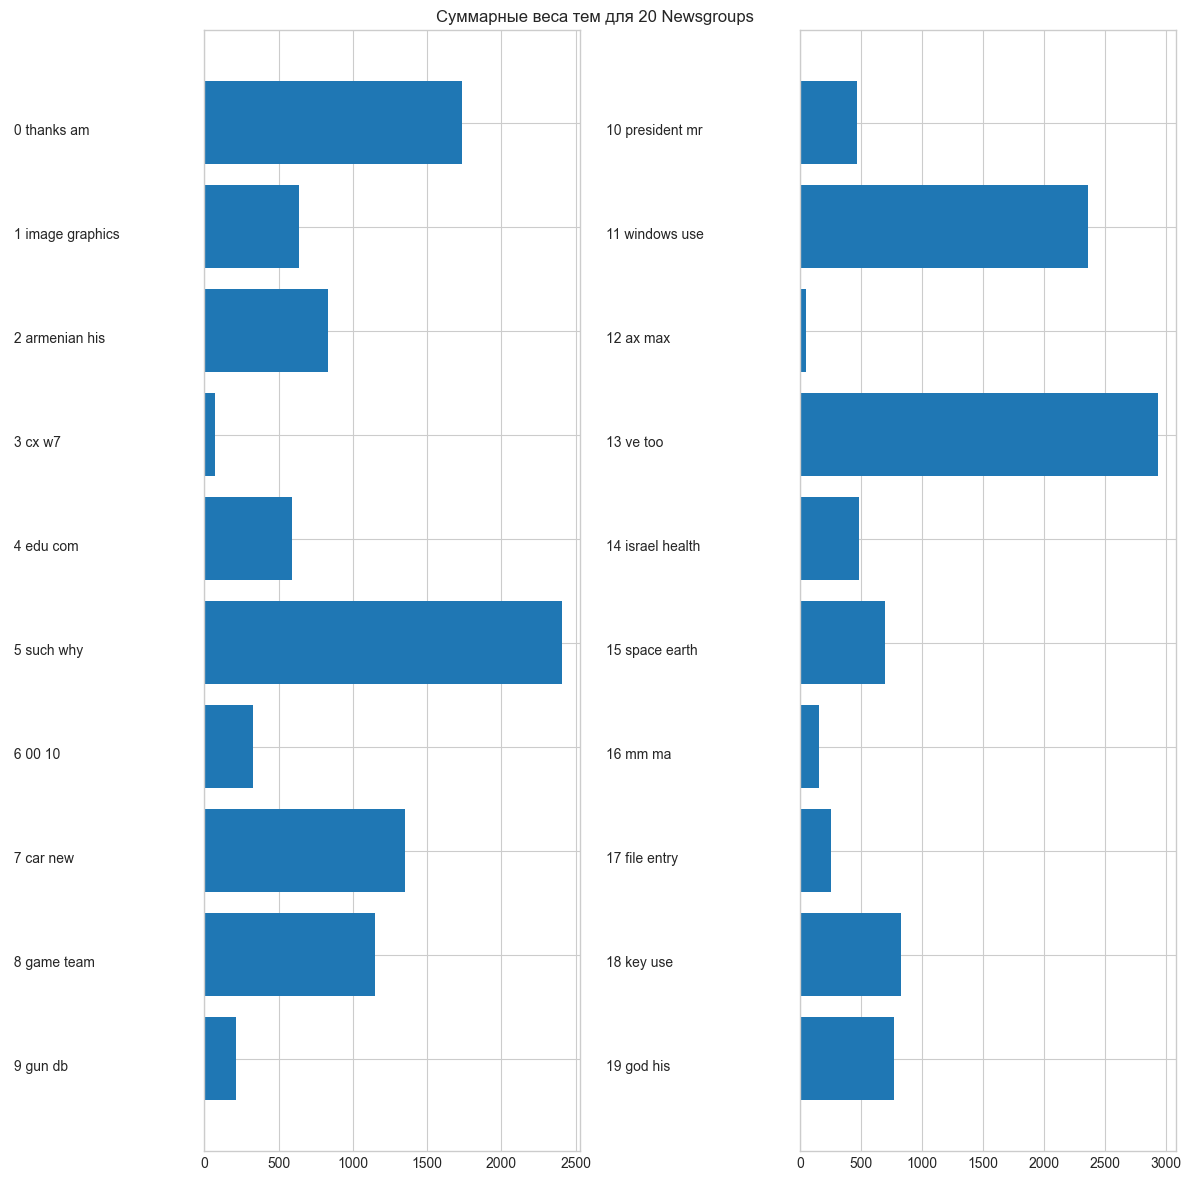

In [11]:
plot_topic_weights(
    document_topics20,
    feature_names,
    sorting20,
    title="Суммарные веса тем для 20 Newsgroups",
)


## Модель LDA с 100 темами


In [12]:
lda100 = LatentDirichletAllocation(
    n_components=100,
    learning_method="batch",
    max_iter=25,
    random_state=0,
)
document_topics100 = lda100.fit_transform(X)


In [13]:
topic_strength100 = np.sum(document_topics100, axis=0)
topics100 = np.argsort(topic_strength100)[-14:]
topics100 = np.sort(topics100)
sorting100 = np.argsort(lda100.components_, axis=1)[:, ::-1]

display(topic_words_df(lda100.components_, feature_names, topics=topics100, n_words=20))


,Тема,Ключевые слова
0,31,"sale, price, offer, new, sell, shipping, condi..."
1,33,"team, game, hockey, season, games, nhl, year, ..."
2,41,"why, say, see, because, here, am, believe, som..."
3,49,"god, his, jesus, christ, him, our, us, lord, s..."
4,50,"god, religion, believe, christian, religious, ..."
5,52,"government, law, right, rights, state, laws, s..."
6,53,"such, evidence, true, argument, these, may, ex..."
7,56,"please, mail, post, send, email, thanks, addre..."
8,67,"car, bike, engine, cars, dod, miles, front, ri..."
9,70,"his, year, him, last, hit, first, good, two, b..."


При `100` темах модель выделяет уже более узкие подтемы. Это делает представление корпуса детальнее, но одновременно повышает требования к интерпретации: часть тем может отличаться лишь небольшими наборами характерных слов.


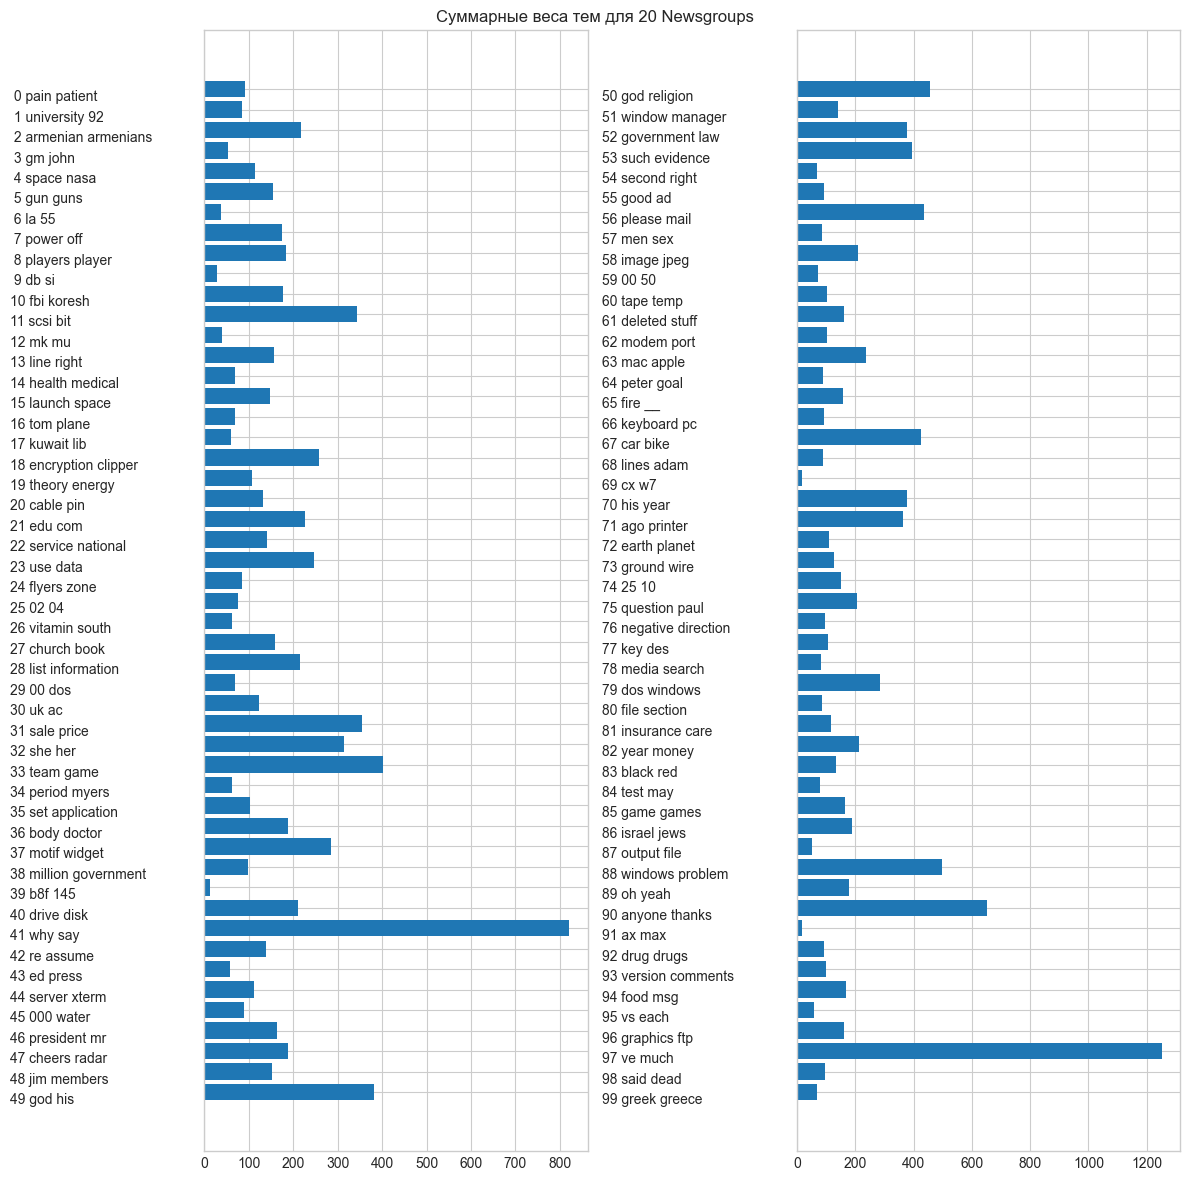

In [14]:
plot_topic_weights(
    document_topics100,
    feature_names,
    sorting100,
    title="Суммарные веса тем для 20 Newsgroups",
)


Диаграмма суммарных весов показывает, какие темы оказываются наиболее выраженными во всем корпусе новостных сообщений. Это позволяет увидеть, какие направления обсуждений доминируют в выбранном датасете.


## Вывод

На другом публичном текстовом датасете был повторен тот же сценарий тематического моделирования, что и в методичке. Помимо моделей `LDA` на `10` и `100` темах дополнительно рассмотрен вариант на `20` темах, совпадающих с числом исходных групп `20 Newsgroups`. Это позволило сравнить грубое, согласованное с разметкой и детализированное представления корпуса. Внешние метрики по доминирующей теме документа дают дополнительную оценку согласованности найденных тем с исходными классами, хотя сама `LDA` по-прежнему остается методом тематического моделирования, а не строгой кластеризации.
